# Group 3 — MEDICAL IMAGE REGRESSION

## Patient Age Prediction from a Random Sample of the NIH Chest X-ray Dataset

| Assignment Requirement               | Notebook Design                                                      |
| ------------------------------------ | -------------------------------------------------------------------- |
| Continuous value from medical images | Patient age in years; image-only input                               |
| NIH ChestX-ray14                     | Random sample; report the actual number of images after verification |
| CNN + GAP + Linear                   | 4 convolutional blocks, `AdaptiveAvgPool2d(1)`, `Linear(256, 1)`     |
| Regression                           | L1/MAE and MSE; no softmax, no argmax                                |
| Compare MAE vs MSE                   | E1/E2 and E3/E4, using the same split and initialization             |
| Test augmentations                   | E1/E3 and E2/E4, with augmentation applied only to the training set  |

### Target Selection

Choose **age**, not tumor size.

Tumor-size regression requires a separate quantitative annotation that provides the actual size of the tumor. The `Mass/Nodule` labels with values `0/1` indicate the presence or absence of a finding, rather than its size.

Therefore, **patient age** is selected as the regression target for this project.


## 1. Problem Statement and Research Objectives

### 1.1. Problem Statement

For each input chest X-ray image $x_i$, the model is required to predict the patient's age $\hat{y}_i$ such that it is as close as possible to the actual age $y_i$ provided in the metadata:

$$
\hat{y}_i = f_\theta(x_i)
$$

where:

* $x_i$: chest X-ray image.
* $y_i$: actual patient age, measured in years.
* $\hat{y}_i$: predicted patient age.
* $\theta$: set of parameters learned by the model from the training set.

The model uses **only the image** as its input. Patient age is used as the target for loss computation, while Patient ID is used only for data splitting and preventing information leakage.

### 1.2. Challenges to Address

1. **Inconsistent age labels:** Age may be represented as a numerical value or as a string containing units; therefore, it must be correctly converted into years.
2. **Different image sizes and quality:** A consistent preprocessing procedure is required before images are fed into the CNN.
3. **Multiple images from the same patient:** Data must be split based on Patient ID to prevent the same patient from appearing in multiple subsets.
4. **Imbalanced age distribution:** Age groups with fewer samples may have larger prediction errors.
5. **Risk of overfitting:** The model may perform well on the training set but poorly on previously unseen patients.
6. **Unfair experimental comparisons:** Experimental conditions must be kept consistent when changing the loss function or augmentation strategy.

### 1.3. Objectives

* Build a pipeline for predicting patient age from chest X-ray images.
* Design a CNN model with Global Average Pooling and a single linear output.
* Compare MAE Loss and MSE Loss using the same dataset and experimental conditions.
* Investigate the effect of data augmentation through controlled experiments.
* Evaluate model performance using MAE, MSE, RMSE, and $R^2$.
* Analyze residuals, large prediction errors, and prediction errors across different age groups.

### 1.4. Research Questions

* Can the CNN predict patient age better than a baseline based on the mean or median age of the training set?
* Under the same training configuration, does MAE Loss or MSE Loss produce lower prediction errors?
* Does data augmentation help reduce prediction errors on unseen data?
* For which age groups does the model tend to overestimate or underestimate the actual patient age?


## 2. Problem Analysis Using What – Why – Who – Where – When – How

| Question                                                            | Coursework Description                                                                                                                                                                                                                        |
| ------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **What — What is being done?**                                      | Build a model to predict a continuous patient age value from chest X-ray images.                                                                                                                                                              |
| **Why — Why is it being conducted?**                                | Apply CNNs to a medical image regression problem and investigate the effects of loss functions and data augmentation on model generalization.                                                                                                 |
| **Who — Who performs the project and who does the data belong to?** | Group 3 conducts the coursework. The dataset consists of patients with images and metadata in the sample; Patient ID is used to ensure patient-level independence between data splits.                                                        |
| **Where — Where is it conducted?**                                  | The Jupyter Notebook is run in VS Code on a local computer; the extracted dataset is loaded from the `DATA_DIR` path.                                                                                                                         |
| **When — When is it conducted?**                                    | Data are checked and cleaned before training; validation performance is evaluated after each epoch; the test set is evaluated only after training is completed and the final configuration has been selected based on validation performance. |
| **How — How is it performed?**                                      | Data verification → patient-level splitting → preprocessing → CNN + GAP + Linear(1) → training E1–E4 → evaluation and error analysis.                                                                                                         |
| **How much — How much data and resources are used?**                | Report the number of images and patients after cleaning, the size of each split, number of epochs, batch size, image size, and the actual computing device used.                                                                              |

### Rationale for Model Selection

**CNN** learns spatial features directly from images without requiring manually engineered features.

**Global Average Pooling** aggregates each feature map into a single value, reducing the number of parameters in the output stage compared with flattening the entire feature map.

**Linear(1)** produces one continuous numerical value for each image, which is appropriate for patient age prediction. The output does not use Softmax or class-selection operations such as `argmax`.

### Interpretation of Results

A lower MAE indicates that the predicted ages are, on average, closer to the actual age labels on the evaluation set.

However, good performance on a single sample does not demonstrate that the model will perform similarly in a hospital setting or on a different population.


## 3. Implementation Pipeline and Experimental Design

### 3.1. Data Preparation

Read `sample_labels.csv` and verify that it contains the required fields: `Image Index`, `Patient ID`, and `Patient Age`.

Convert patient age to years, apply the valid-age criteria, and check for missing images, corrupted images, and duplicate images.

All excluded cases must be counted and reported clearly so that the actual dataset used in the experiments can be documented.

### 3.2. Data Splitting

The dataset is divided into training, validation, and test sets based on **Patient ID**, with an expected ratio of approximately 70%, 15%, and 15%, respectively.

Because the split is performed at the patient level, the actual image proportions may differ slightly from these target ratios.

* **Training set:** Used to update model parameters.
* **Validation set:** Used for checkpoint selection and configuration selection.
* **Test set:** Used for final evaluation after the model configuration has been finalized.

### 3.3. Preprocessing and Data Augmentation

The images are converted to grayscale, resized while preserving their aspect ratio, padded to the required input size, and normalized.

Data augmentation uses mild transformations according to the notebook configuration and is applied **only to the training set**.

The validation and test sets use the same deterministic preprocessing pipeline without random augmentation.

Patient age is divided by 100 during optimization. When calculating evaluation metrics, the predicted and actual values are converted back to the original unit of years.

### 3.4. Experimental Matrix

| Experiment | Loss | Augmentation |
| ---------- | ---- | ------------ |
| E1         | MSE  | No           |
| E2         | MAE  | No           |
| E3         | MSE  | Yes          |
| E4         | MAE  | Yes          |

All experiments use the same:

* Dataset split
* Initialization seed
* Model architecture
* Optimizer
* Learning rate
* Batch size
* Number of training epochs

The experimental comparisons are defined as follows:

* **E1 vs. E2:** Effect of the loss function without augmentation.
* **E3 vs. E4:** Effect of the loss function with augmentation.
* **E1 vs. E3:** Effect of augmentation when using MSE.
* **E2 vs. E4:** Effect of augmentation when using MAE.

### 3.5. Model Selection

For each experiment, the checkpoint with the **lowest validation MAE** is retained.

After completing E1–E4, the final configuration is selected based on validation MAE, and only then is the test set evaluated.

The test results are used to report the predefined experiments. The test set is **not** used to further tune the model or select another configuration.

Results obtained from a single random seed represent a comparison within the tested configurations only. They are not sufficient to conclude that one loss function will always outperform the other.


## 4. Results Evaluation and Completion Criteria

### 4.1. Evaluation Metrics

| Metric | Meaning                                                                                           | Unit     |
| ------ | ------------------------------------------------------------------------------------------------- | -------- |
| MAE    | Mean absolute difference between predicted and actual age                                         | Years    |
| MSE    | Mean squared error, which emphasizes large errors                                                 | Years²   |
| RMSE   | Square root of MSE, sensitive to large prediction errors                                          | Years    |
| $R^2$  | Compares the residual sum of squares with the variation around the mean age of the evaluation set | Unitless |
| Bias   | Mean predicted age minus actual age                                                               | Years    |

Lower MAE and RMSE values indicate smaller prediction errors.

A positive Bias indicates a tendency to predict patients as older than their actual age, while a negative Bias indicates a tendency to predict patients as younger than their actual age.

A negative $R^2$ means that the model has a residual sum of squares larger than the approach that always predicts the mean age of the evaluation set.

The baseline implemented in the notebook is calculated separately from the training set to avoid using information from the test set.

### 4.2. Baseline Comparison

Two simple baselines are used for comparison:

* **Train-mean baseline:** Always predicts the mean patient age calculated from the training set.
* **Train-median baseline:** Always predicts the median patient age calculated from the training set.

The CNN is not assumed to outperform the baselines by default. Its performance must be compared with the baselines using the actual experimental results.

### 4.3. Interpreting Visualizations

* **Loss and MAE curves:** Monitor the learning process and identify potential signs of overfitting.
* **Actual vs. Predicted:** Points closer to the $y=x$ line indicate smaller prediction errors.
* **Residual histogram:** Examine the distribution, bias, and tails of the prediction errors.
* **Residuals vs. Age:** Identify tendencies to overpredict or underpredict for different age groups.
* **MAE by Age Group:** Evaluate performance across different age groups, including groups with fewer samples.
* **Examples with Small/Large Errors:** Illustrate cases where the model performs well or cases that require further analysis.

Examples selected based on extreme prediction errors are not representative of the entire test set and do not, by themselves, demonstrate the cause of the model's prediction errors.

### 4.4. Completion Criteria

The coursework is considered complete when:

* The dataset has been checked and no Patient ID overlap exists between the different splits.
* All four experiments, E1–E4, have been completed under consistent comparison conditions.
* Metrics, learning curves, prediction records, and model checkpoints have been saved.
* The results have been compared with the baselines and prediction errors have been analyzed across age groups.
* The actual experimental configuration, dataset limitations, and limitations of using a single random seed have been documented.
* The conclusions are based on actual experimental outputs rather than smoke-test results.

### 4.5. Conclusion Template After Running the Experiments

The group selected **[experiment name]** based on the lowest validation MAE. On the test set, the model achieved an MAE of **[...] years**, an RMSE of **[...] years**, and an $R^2$ of **[...]**.

Compared with the train-mean baseline, the MAE **[decreased/increased] by [...] years**. Comparison across the experimental pairs shows that the effect of the loss function was **[...]**, while the effect of data augmentation was **[...]**.

The largest prediction errors were concentrated in **[observed age group/cases]**. These conclusions apply only within the scope of the current NIH Random Sample and experimental design and are not sufficient to establish clinical usability.


In [1]:
from pathlib import Path
import os, re, json, random, hashlib, platform, sys
from datetime import datetime
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from IPython.display import display, Markdown
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

# CẤU HÌNH DUY NHẤT: dùng đường dẫn thư mục, không phải file ZIP.
DATA_DIR = Path(r"archive (5)")
CSV_FILE = None  # Nếu có nhiều CSV khác nhau: Path(r"D:\...\sample_labels.csv")
MODE = "full"  # check / smoke / full / reload
RUN_DIR = None  # reload: Path(r"D:\...\nih_runs\full_...")
OUT_ROOT = Path.cwd() / "nih_runs"
SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10
LR = 1e-3
WEIGHT_DECAY = 1e-4
AGE_SCALE = 100.0
MIN_AGE, MAX_AGE = 1.0, 100.0  # Tiêu chí phạm vi nghiên cứu, không sửa nhãn gốc.
VERIFY_IMAGES = True
NUM_WORKERS = 0  # An toàn cho Windows/Jupyter.
assert MODE in {"check", "smoke", "full", "reload"}
assert EPOCHS > 0 and BATCH_SIZE > 0 and IMAGE_SIZE >= 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_all(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_all(SEED)
print("Working directory:", Path.cwd())
print("Device:", DEVICE, "| PyTorch:", torch.__version__, "| Mode:", MODE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Working directory: d:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\CourseWork
Device: cuda | PyTorch: 2.13.0+cu126 | Mode: full
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


## 1. Identify the Correct Extracted Dataset

This cell only searches for the sample dataset within directories near the notebook and does **not** scan the entire drive.

If multiple identical CSV copies are found, one copy is selected. If the files contain different content, the process is stopped so that `CSV_FILE` can be specified manually.


In [2]:
if not DATA_DIR.is_absolute() and not DATA_DIR.exists():
    candidates = [Path.cwd()/"CourseWork"/DATA_DIR,
                  Path.cwd().parent/DATA_DIR,
                  Path.cwd().parent.parent/DATA_DIR]
    found = [p for p in candidates if p.is_dir()]
    if len(found) == 1:
        DATA_DIR = found[0]
if not DATA_DIR.is_dir():
    raise FileNotFoundError(
        f"Không thấy thư mục {DATA_DIR.resolve()}. Sửa DATA_DIR bằng đường dẫn "
        "tuyệt đối đến archive (5) đã GIẢI NÉN trên máy bạn.")
DATA_DIR = DATA_DIR.resolve()
if CSV_FILE is None:
    candidates = sorted(DATA_DIR.rglob("sample_labels.csv"))
    if not candidates:
        raise FileNotFoundError("Không thấy sample_labels.csv bên dưới DATA_DIR.")
    hashes = {hashlib.sha256(p.read_bytes()).hexdigest() for p in candidates}
    if len(hashes) > 1:
        display(pd.DataFrame({"CSV candidates": [str(p) for p in candidates]}))
        raise ValueError("CSV khác nội dung. Hãy chỉ định CSV_FILE trong cell cấu hình.")
    CSV_FILE = min(candidates, key=lambda p: len(p.parts))
CSV_FILE = Path(CSV_FILE).resolve()
raw = pd.read_csv(CSV_FILE, dtype={"Patient ID": str})
raw.columns = raw.columns.str.strip()
required = {"Image Index", "Patient ID", "Patient Age"}
if required - set(raw.columns):
    raise ValueError(f"Thiếu cột: {required - set(raw.columns)}. Không dùng nhãn bệnh làm tuổi.")
print("Metadata:", CSV_FILE)
print("Số dòng ban đầu:", len(raw))
display(raw.head())


Metadata: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\CourseWork\archive (5)\sample_labels.csv
Số dòng ban đầu: 5606


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,00000013,060Y,M,AP,3056,2544,0.139,0.139
1,00000013_026.png,Cardiomegaly|Emphysema,26,00000013,057Y,M,AP,2500,2048,0.168,0.168
2,00000017_001.png,No Finding,1,00000017,077Y,M,AP,2500,2048,0.168,0.168
3,00000030_001.png,Atelectasis,1,00000030,079Y,M,PA,2992,2991,0.143,0.143
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,00000032,055Y,F,AP,2500,2048,0.168,0.168


## 2. Age and Data Quality — Do Not Strip Units

Patient age may be represented as a numerical value or as a string such as `058Y`, `018M`, `010D`.

Do not extract only the numerical part using a regular expression and treat every value as years. For example, `018M` represents **1.5 years**, not 18 years.

The function below converts `Y/M/W/D` into years, preserves decimal values, and removes values that cannot be interpreted.

The age range of **1–100 years** is the cohort selection criterion for this project and must be explicitly reported.

Images that cannot be opened, records with missing metadata, and duplicate image files with identical content are recorded in the audit.

If the same filename corresponds to different image contents, the process is stopped rather than arbitrarily selecting one of the images.


In [3]:
def parse_age_years(value):
    if pd.isna(value):
        return np.nan
    match = re.fullmatch(r"(\d+(?:\.\d+)?)\s*([YMWD]?)", str(value).strip().upper())
    if not match:
        return np.nan
    number, unit = float(match[1]), match[2]
    return number * {"": 1.0, "Y": 1.0, "M": 1/12, "W": 7/365.25, "D": 1/365.25}[unit]

df = raw.copy()
df["age"] = df["Patient Age"].map(parse_age_years)
df["Image Index"] = df["Image Index"].astype("string").str.strip()
df["Patient ID"] = df["Patient ID"].astype("string").str.strip()
valid = (df["age"].between(MIN_AGE, MAX_AGE)
         & df["Image Index"].notna() & df["Patient ID"].notna()
         & df["Image Index"].ne("") & df["Patient ID"].ne(""))
excluded_metadata = df.loc[~valid].copy()
df = df.loc[valid].copy()
conflict = df.groupby("Image Index")[["age", "Patient ID"]].nunique().gt(1).any(axis=1)
if conflict.any():
    raise ValueError("Cùng ảnh có nhiều tuổi/Patient ID khác nhau; cần kiểm tra metadata.")
df = df.drop_duplicates("Image Index")
files = defaultdict(list)
for p in DATA_DIR.rglob("*"):
    if p.is_file() and p.suffix.lower() in {".png", ".jpg", ".jpeg"}:
        files[p.name].append(p)

records, image_issues = [], []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Kiểm tra ảnh"):
    matches = sorted(files.get(row["Image Index"], []))
    if not matches:
        image_issues.append({"image": row["Image Index"], "reason": "missing"})
        continue
    digests = {hashlib.sha256(p.read_bytes()).hexdigest() for p in matches}
    if len(digests) != 1:
        raise ValueError(f"Filename trùng nhưng nội dung khác: {row['Image Index']}")
    p = matches[0]
    try:
        with Image.open(p) as im:
            width, height = im.size
            if VERIFY_IMAGES:
                im.verify()
    except (OSError, ValueError) as exc:
        image_issues.append({"image": row["Image Index"], "reason": str(exc)})
        continue
    record = row.to_dict()
    record.update(image_path=str(p), sha256=next(iter(digests)), width=width, height=height)
    records.append(record)
df = pd.DataFrame(records)
if df.empty:
    raise RuntimeError("Không có cặp ảnh–tuổi hợp lệ. Kiểm tra DATA_DIR và metadata.")
duplicate_content = df[df.duplicated("sha256", keep="first")].copy()
df = df.drop_duplicates("sha256").reset_index(drop=True)
audit = pd.DataFrame([
    ["Metadata ban đầu", len(raw)],
    ["Metadata ngoài tiêu chí/không hợp lệ", len(excluded_metadata)],
    ["Ảnh thiếu/lỗi", len(image_issues)],
    ["Ảnh trùng nội dung bị loại", len(duplicate_content)],
    ["Ảnh dùng được", len(df)],
    ["Bệnh nhân dùng được", df["Patient ID"].nunique()],
], columns=["Hạng mục", "Số lượng"])
display(audit)
display(df[["age", "width", "height"]].describe().round(2))


Kiểm tra ảnh:   0%|          | 0/5604 [00:00<?, ?it/s]

,Hạng mục,Số lượng
0,Metadata ban đầu,5606
1,Metadata ngoài tiêu chí/không hợp lệ,2
2,Ảnh thiếu/lỗi,0
3,Ảnh trùng nội dung bị loại,0
4,Ảnh dùng được,5604
5,Bệnh nhân dùng được,4228


,age,width,height
count,5604.00,5604.0,5604.0
mean,46.71,1024.0,1024.0
std,16.71,0.0,0.0
min,1.08,1024.0,1024.0
25%,35.00,1024.0,1024.0
50%,49.00,1024.0,1024.0
75%,59.00,1024.0,1024.0
max,94.00,1024.0,1024.0


### EDA Remarks to Report

Use the number of **usable images** after data verification as the experimental sample size. Do not automatically assume the sample size is 5,606 or 112,120.

Compare the **median age**, **minimum and maximum age**, and the **number of images per patient**.

Multiple images from the same patient should not be treated as multiple independent observations.


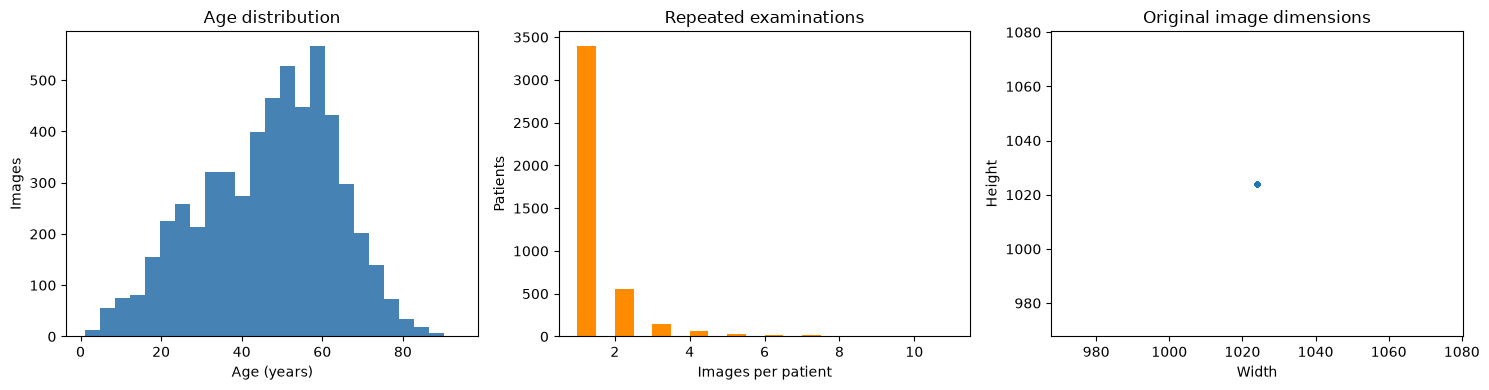

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df.age, bins=25, color="steelblue")
axes[0].set(xlabel="Age (years)", ylabel="Images", title="Age distribution")
axes[1].hist(df.groupby("Patient ID").size(), bins=20, color="darkorange")
axes[1].set(xlabel="Images per patient", ylabel="Patients", title="Repeated examinations")
axes[2].scatter(df.width, df.height, alpha=.25, s=8)
axes[2].set(xlabel="Width", ylabel="Height", title="Original image dimensions")
plt.tight_layout(); plt.show()


## 3. Patient-Level Data Splitting — Approximately 70/15/15

Patient IDs must not overlap between the different data splits. The image proportions may not be exactly 70/15/15 because the split is performed at the **patient level**.

The same fixed split must be used for all experiments E1–E4.

Do not repeatedly re-split the dataset until obtaining favorable test results.

The `smoke` subset should only be created from a small sample **after** the main patient-level split has been completed.


,split,images,patients,mean_age,min_age,max_age
0,train,3956,2959,46.54,2.00,94.0
1,val,824,634,47.73,1.08,89.0
2,test,824,635,46.51,2.00,85.0


PASS: không giao bệnh nhân và không trùng file ảnh giữa các split.


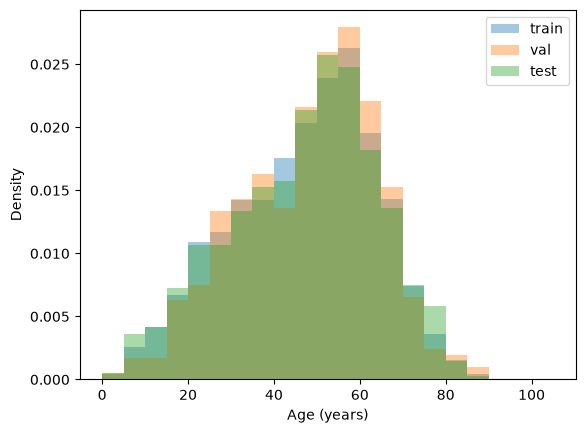

In [5]:
g = GroupShuffleSplit(n_splits=1, test_size=.30, random_state=SEED)
tr, rest = next(g.split(df, groups=df["Patient ID"]))
temporary = df.iloc[rest]
g2 = GroupShuffleSplit(n_splits=1, test_size=.50, random_state=SEED)
va, te = next(g2.split(temporary, groups=temporary["Patient ID"]))
splits = {"train": df.iloc[tr].copy(), "val": temporary.iloc[va].copy(),
          "test": temporary.iloc[te].copy()}
if MODE == "smoke":
    splits = {k: v.sample(min(len(v), 64 if k == "train" else 32), random_state=SEED)
              for k, v in splits.items()}
if MODE == "reload":
    if RUN_DIR is None:
        raise ValueError("reload yêu cầu RUN_DIR của lần chạy trước.")
    RUN_DIR = Path(RUN_DIR)
    saved_config = json.loads((RUN_DIR/"config.json").read_text(encoding="utf-8"))
    if saved_config["metadata_sha256"] != hashlib.sha256(CSV_FILE.read_bytes()).hexdigest():
        raise ValueError("Metadata khác lần chạy đã lưu.")
    restored = {}
    for k in splits:
        saved = pd.read_csv(RUN_DIR/f"{k}_split.csv", dtype={"Patient ID": str})
        joined = saved[["Image Index", "Patient ID", "age", "sha256"]].merge(
            df[["Image Index", "Patient ID", "age", "sha256", "image_path"]],
            on=["Image Index", "Patient ID", "age", "sha256"], validate="one_to_one")
        if len(joined) != len(saved):
            raise ValueError("Dataset hiện tại không khớp manifest đã lưu.")
        restored[k] = joined
    splits = restored
for k in splits:
    splits[k] = splits[k].reset_index(drop=True)
for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
    assert set(splits[a]["Patient ID"]).isdisjoint(splits[b]["Patient ID"])
    assert set(splits[a].sha256).isdisjoint(splits[b].sha256)
summary = pd.DataFrame([{"split": k, "images": len(v),
    "patients": v["Patient ID"].nunique(), "mean_age": v.age.mean(),
    "min_age": v.age.min(), "max_age": v.age.max()} for k,v in splits.items()])
display(summary.round(2))
print("PASS: không giao bệnh nhân và không trùng file ảnh giữa các split.")
for k,v in splits.items():
    plt.hist(v.age, bins=np.arange(0, 106, 5), density=True, alpha=.4, label=k)
plt.xlabel("Age (years)"); plt.ylabel("Density"); plt.legend(); plt.show()


## 4. Controlled Preprocessing and Data Augmentation

Convert images to grayscale, resize them while preserving their aspect ratio, and pad them to a square format. Normalize the images using the constant value **0.5**, without learning normalization statistics from the test set.

The main augmentation strategy uses:

* Rotation of ±7°
* Translation of ±3%
* Scaling between 0.95 and 1.05

Horizontal flipping is **not used by default** because it reverses anatomical laterality. This is a conservative design choice and does not imply that horizontal flipping is always inappropriate.

The target age is divided by 100 during optimization. Evaluation metrics and visualization outputs are always converted back to the original unit of **years**.


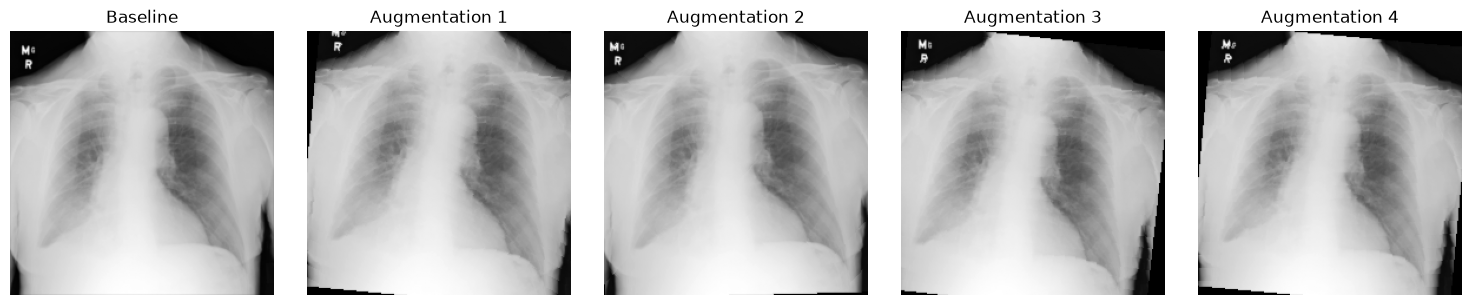

Input: (16, 1, 224, 224) | Target: (16,)


In [6]:
class Letterbox:
    def __init__(self, size): self.size = size
    def __call__(self, image):
        return ImageOps.pad(image, (self.size, self.size),
                            method=Image.Resampling.BILINEAR, color=0)

base = [Letterbox(IMAGE_SIZE)]
tail = [transforms.ToTensor(), transforms.Normalize([.5], [.5])]
eval_tf = transforms.Compose(base + tail)
aug_tf = transforms.Compose(base + [transforms.RandomAffine(
    degrees=7, translate=(.03, .03), scale=(.95, 1.05), fill=0)] + tail)

class AgeDataset(Dataset):
    def __init__(self, frame, tf): self.frame, self.tf = frame.reset_index(drop=True), tf
    def __len__(self): return len(self.frame)
    def __getitem__(self, i):
        row = self.frame.iloc[i]
        with Image.open(row.image_path) as im:
            x = self.tf(im.convert("L"))
        return x, torch.tensor(row.age/AGE_SCALE, dtype=torch.float32)

def loader(frame, tf, shuffle=False):
    return DataLoader(AgeDataset(frame, tf), batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda",
                      generator=torch.Generator().manual_seed(SEED))

with Image.open(splits["train"].iloc[0].image_path) as im:
    original = im.convert("L")
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    for j,ax in enumerate(axes):
        x = (eval_tf if j == 0 else aug_tf)(original)
        ax.imshow((x.squeeze().numpy()*.5+.5).clip(0,1), cmap="gray")
        ax.set_title("Baseline" if j == 0 else f"Augmentation {j}"); ax.axis("off")
    plt.tight_layout(); plt.show()
xb, yb = next(iter(loader(splits["train"], eval_tf)))
print("Input:", tuple(xb.shape), "| Target:", tuple(yb.shape))


## 5. Model Architecture: CNN → GAP → Linear Output

Four **Conv–BatchNorm–ReLU–MaxPool** blocks are used to learn visual representations from the chest X-ray images.

**Global Average Pooling (GAP)** computes the spatial average of each feature map, reducing the spatial dimensions while retaining the learned feature representations.

The final `Linear` layer has exactly **one output**, which produces the predicted patient age.

No `sigmoid` or `softmax` activation is used because this is a regression task.

Patient age and `Patient ID` are **not** provided as model inputs. The model receives only the chest X-ray image.

Predictions outside the valid age range are **not clipped** when calculating evaluation metrics, because clipping could hide or reduce the apparent magnitude of model errors.


In [7]:
class AgeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        blocks = []
        for cin, cout in [(1,32), (32,64), (64,128), (128,256)]:
            blocks += [nn.Conv2d(cin,cout,3,padding=1), nn.BatchNorm2d(cout),
                       nn.ReLU(), nn.MaxPool2d(2)]
        self.features = nn.Sequential(*blocks)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.output = nn.Linear(256,1)
    def forward(self,x): return self.output(self.gap(self.features(x)).flatten(1))

seed_all(SEED)
probe = AgeCNN().to(DEVICE).eval()
with torch.no_grad():
    yp = probe(xb.to(DEVICE))
assert yp.shape == (len(xb),1)
print(probe)
print("Trainable parameters:", sum(p.numel() for p in probe.parameters() if p.requires_grad))
print("Output shape:", tuple(yp.shape))
del probe


AgeCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=T

## 6. Loss Functions and Evaluation Criteria

The main evaluation metrics are defined as follows:

$$
MAE=\frac{1}{n}\sum|\hat{y}-y|,\qquad
MSE=\frac{1}{n}\sum(\hat{y}-y)^2,\qquad
RMSE=\sqrt{MSE}.
$$

MAE is measured in **years**, MSE in **years²**, and RMSE in **years**.

MSE penalizes large residuals more strongly because the errors are squared. MAE is less sensitive to outliers. However, it is not possible to conclude which loss function is better before conducting the experiments.

The loss optimization uses the target age scaled by 100:

* `L1 × 100` corresponds to the error in years.
* `MSE × 10,000` corresponds to the error in years².

Therefore, the raw loss magnitudes of MAE and MSE should **not** be directly compared on the same scale as if they represented the same quantity.

The coefficient of determination is defined as:

$$
R^2=1-\frac{SSE}{SST}
$$

where `SST` is calculated around the **mean age of the evaluated set**.

A negative $R^2$ means that the model performs worse, in terms of squared error, than the constant prediction equal to the mean age of that same evaluation set. This does not necessarily mean that the model performs worse than the train-mean baseline.

The following baselines are therefore reported separately:

* **Train-mean baseline**
* **Train-median baseline**

Bias is defined as:

$$
Bias = mean(\text{predicted age} - \text{actual age})
$$

A positive Bias indicates a tendency to predict patients as older than their actual age, while a negative Bias indicates a tendency to predict patients as younger.

Additional metrics, including **Median Absolute Error (Median AE)** and **90th Percentile Absolute Error (P90 AE)**, are reported to provide more information about the typical prediction error and the tail of the error distribution.


In [8]:
def metrics(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    e = p-y
    return {"MAE": float(np.abs(e).mean()), "MSE": float((e**2).mean()),
            "RMSE": float(np.sqrt((e**2).mean())),
            "R2": float(r2_score(y,p)) if len(y)>1 and np.var(y)>0 else np.nan,
            "Bias": float(e.mean()), "Median_AE": float(np.median(np.abs(e))),
            "P90_AE": float(np.quantile(np.abs(e),.9))}

EXPERIMENTS = [("E1", "MSE", False), ("E2", "MAE", False),
               ("E3", "MSE", True), ("E4", "MAE", True)]
display(pd.DataFrame(EXPERIMENTS, columns=["ID","Loss","Augmentation"]))


,ID,Loss,Augmentation
0,E1,MSE,False
1,E2,MAE,False
2,E3,MSE,True
3,E4,MAE,True


## 7. Training E1–E4 — Validation First, Test Last

All four experiments use the same:

* Dataset split
* Initialization seed
* DataLoader seed
* Batch size
* Number of training epochs
* AdamW optimizer
* Learning rate

No early stopping is used so that all four experiments are trained for the same number of epochs.

For each experiment, the checkpoint with the **lowest validation MAE** is selected.

Using the same learning rate provides a comparison under a common training recipe; it does not demonstrate that one loss function is optimal after hyperparameter tuning.

A single random seed is not sufficient to measure the stability or variability of the results across different initializations.

### Test Set Isolation

**The test set must not be accessed during training.**

After all four experiments have been completed, the final configuration is selected based on validation performance. Only then is the fixed test evaluation performed.

The test results must not be used to tune the model, adjust hyperparameters, or select another configuration.

### Checkpoint and Training History

A model checkpoint and training history are saved after each epoch.

This ensures that intermediate results are preserved and that the entire training process does not have to be repeated if the notebook, computer, or training process is interrupted.


In [9]:
def epoch_pass(model, dl, criterion, optimizer=None):
    model.train(optimizer is not None)
    total, ys, ps = 0., [], []
    for x,y in tqdm(dl, leave=False):
        x,y = x.to(DEVICE), y.to(DEVICE)
        if optimizer is not None: optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(optimizer is not None):
            p = model(x).squeeze(1)
            assert p.shape == y.shape
            loss = criterion(p,y)
            if not torch.isfinite(loss): raise FloatingPointError("Loss không hữu hạn.")
            if optimizer is not None:
                loss.backward(); optimizer.step()
        total += loss.item()*len(x)
        ys.extend((y.detach().cpu().numpy()*AGE_SCALE).tolist())
        ps.extend((p.detach().cpu().numpy()*AGE_SCALE).tolist())
    return {"loss": total/len(dl.dataset), **metrics(ys,ps)}, np.array(ys), np.array(ps)

config = dict(mode=MODE, seed=SEED, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
              epochs=1 if MODE=="smoke" else EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
              age_scale=AGE_SCALE, age_range=[MIN_AGE,MAX_AGE],
              augmentation="affine ±7deg, translate .03, scale .95–1.05",
              metadata_sha256=hashlib.sha256(CSV_FILE.read_bytes()).hexdigest(),
              python=sys.version, torch=str(torch.__version__), device=str(DEVICE))
histories, validation_rows = {}, []
if MODE in {"full", "smoke"}:
    RUN_DIR = OUT_ROOT / (MODE + "_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f"))
    RUN_DIR.mkdir(parents=True, exist_ok=False)
    (RUN_DIR/"config.json").write_text(json.dumps(config,indent=2,ensure_ascii=False),encoding="utf-8")
    for k,v in splits.items(): v.to_csv(RUN_DIR/f"{k}_split.csv", index=False)
    audit.to_csv(RUN_DIR/"data_audit.csv",index=False)
    excluded_metadata.to_csv(RUN_DIR/"excluded_metadata.csv",index=False)
    pd.DataFrame(image_issues).to_csv(RUN_DIR/"image_issues.csv",index=False)
    duplicate_content.to_csv(RUN_DIR/"duplicate_images.csv",index=False)
    for eid,loss_name,aug in EXPERIMENTS:
        seed_all(SEED)
        model = AgeCNN().to(DEVICE)
        criterion = nn.MSELoss() if loss_name=="MSE" else nn.L1Loss()
        optimizer = torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
        tr_dl = loader(splits["train"], aug_tf if aug else eval_tf, True)
        va_dl = loader(splits["val"], eval_tf)
        best, best_epoch, rows = float("inf"), None, []
        for ep in range(1, config["epochs"]+1):
            trm,_,_ = epoch_pass(model,tr_dl,criterion,optimizer)
            vam,_,_ = epoch_pass(model,va_dl,criterion)
            rows.append({"epoch":ep, **{f"train_{k}":v for k,v in trm.items()},
                         **{f"val_{k}":v for k,v in vam.items()}})
            if vam["MAE"] < best:
                best,best_epoch = vam["MAE"],ep
                state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
                torch.save({"state_dict":state,"experiment":eid,"loss":loss_name,
                            "augmentation":aug,"epoch":ep,"val_mae":best,
                            "image_size":IMAGE_SIZE,"age_scale":AGE_SCALE}, RUN_DIR/f"{eid}_best.pth")
            pd.DataFrame(rows).to_csv(RUN_DIR/f"{eid}_history.csv",index=False)
            print(f"{eid} | {ep}/{config['epochs']} | train MAE {trm['MAE']:.3f} | val MAE {vam['MAE']:.3f} năm")
        histories[eid] = pd.DataFrame(rows)
        validation_rows.append(dict(experiment=eid, loss=loss_name, augmentation=aug,
                                    best_epoch=best_epoch, val_MAE=best))
        del model, optimizer
        if DEVICE.type=="cuda": torch.cuda.empty_cache()
    validation_results = pd.DataFrame(validation_rows)
    validation_results.to_csv(RUN_DIR/"validation_results.csv",index=False)
elif MODE=="reload":
    config = saved_config
    validation_results = pd.read_csv(RUN_DIR/"validation_results.csv")
    histories = {eid:pd.read_csv(RUN_DIR/f"{eid}_history.csv") for eid,_,_ in EXPERIMENTS}
else:
    print("CHECK hoàn thành. Chọn MODE='smoke' hoặc 'full', Restart Kernel → Run All.")

trained = MODE != "check"
if trained:
    selected = str(validation_results.sort_values(["val_MAE","experiment"]).iloc[0].experiment)
    display(validation_results)
    print("Cấu hình được chọn CHỈ theo validation:",selected)
    print("Kết quả lưu ở:",RUN_DIR.resolve())


  0%|          | 0/248 [00:00<?, ?it/s]

  0%|          | 0/52 [00:00<?, ?it/s]

E1 | 1/10 | train MAE 13.899 | val MAE 12.805 năm


  0%|          | 0/248 [00:00<?, ?it/s]

  0%|          | 0/52 [00:00<?, ?it/s]

...

  0%|          | 0/248 [00:00<?, ?it/s]

  0%|          | 0/52 [00:00<?, ?it/s]

E4 | 10/10 | train MAE 13.146 | val MAE 13.038 năm


,experiment,loss,augmentation,best_epoch,val_MAE
0,E1,MSE,False,9,11.323900
1,E2,MAE,False,9,11.790808
2,E3,MSE,True,10,11.258113
3,E4,MAE,True,9,12.569042


Cấu hình được chọn CHỈ theo validation: E3
Kết quả lưu ở: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\CourseWork\nih_runs\full_20260925_191518_261037


## 8. Learning curves có lưu hình

Mỗi hàng là một thí nghiệm: bên trái loss tối ưu, bên phải MAE theo năm.
Train MAE đo trong training mode và có augmentation ở E3/E4, còn validation đo
ở evaluation mode; vì vậy khoảng cách hai đường không chỉ do overfitting.
Train giảm liên tục trong khi validation tăng kéo dài là dấu hiệu cần kiểm tra.


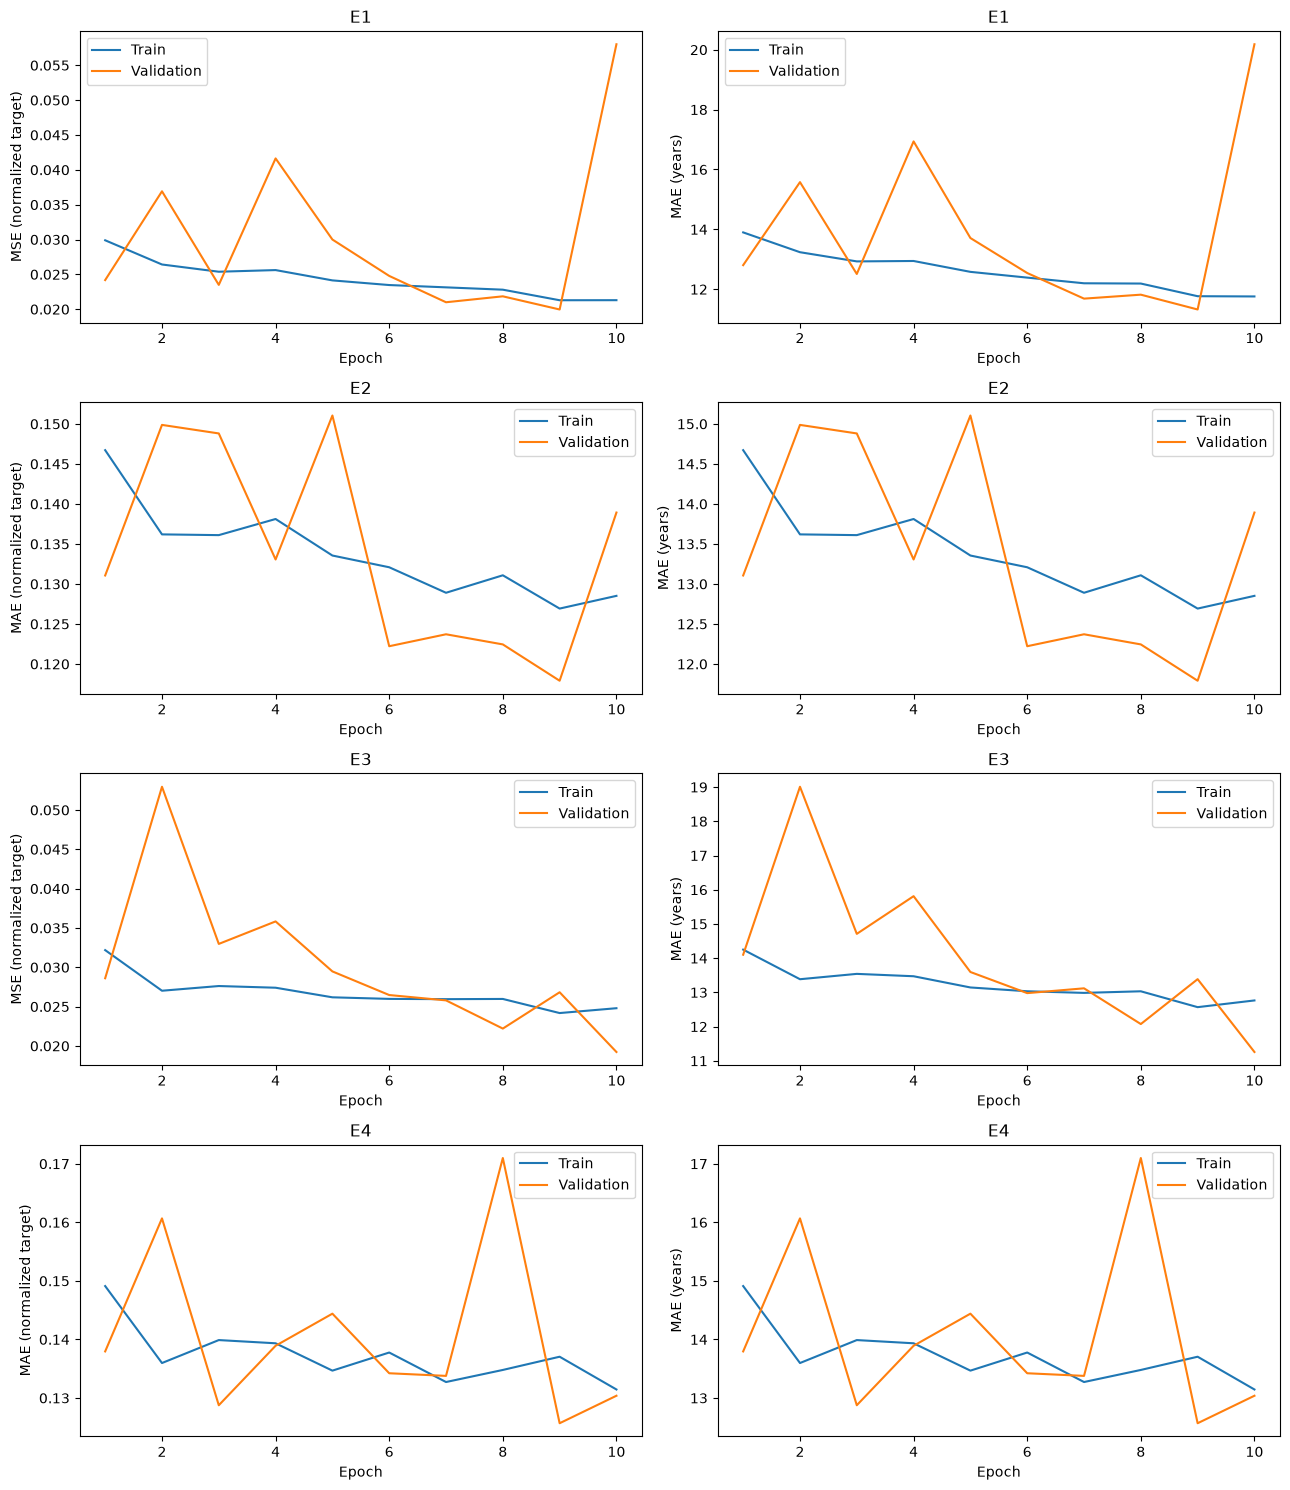

In [10]:
def save_figure(name):
    if trained:
        folder = RUN_DIR/"figures"; folder.mkdir(exist_ok=True)
        plt.gcf().savefig(folder/f"{name}.png",dpi=150,bbox_inches="tight")
    plt.show()

if trained:
    fig,axes = plt.subplots(4,2,figsize=(13,15))
    for i,(eid,loss_name,_) in enumerate(EXPERIMENTS):
        h = histories[eid]
        for j,(key,label) in enumerate([("loss",f"{loss_name} (normalized target)"),("MAE","MAE (years)")]):
            axes[i,j].plot(h.epoch,h[f"train_{key}"],label="Train")
            axes[i,j].plot(h.epoch,h[f"val_{key}"],label="Validation")
            axes[i,j].set(title=eid,xlabel="Epoch",ylabel=label)
            axes[i,j].legend()
    plt.tight_layout(); save_figure("learning_curves")


## 9. Test Evaluation After Finalizing Model Selection

The two baseline models use the **mean and median age calculated from the training set**, not from the test set.

The test results table is used to report the predefined E1–E4 experiments and is **not** used to select or re-select an experiment.

When using `reload`, the notebook reads the previously saved results CSV files instead of running the test evaluation again.

Each prediction CSV stores the following information for traceability:

* Image filename
* Patient ID
* Actual age
* Predicted age
* Residual
* Absolute error

This allows individual predictions to be traced back to the corresponding image and patient record for further analysis.


  0%|          | 0/52 [00:00<?, ?it/s]

  0%|          | 0/52 [00:00<?, ?it/s]

  0%|          | 0/52 [00:00<?, ?it/s]

  0%|          | 0/52 [00:00<?, ?it/s]

,experiment,MAE,MSE,RMSE,R2,Bias,Median_AE,P90_AE
0,E1,11.695,209.362,14.469,0.291,-5.678,10.019,23.566
1,E2,11.828,215.660,14.685,0.270,-2.809,10.548,23.382
2,E3,11.432,201.957,14.211,0.316,0.576,9.789,22.961
3,E4,12.592,237.007,15.395,0.198,-4.559,11.289,25.075
4,Train mean,14.107,295.401,17.187,-0.000,0.028,12.460,28.540
5,Train median,13.942,301.590,17.366,-0.021,2.488,12.000,29.000


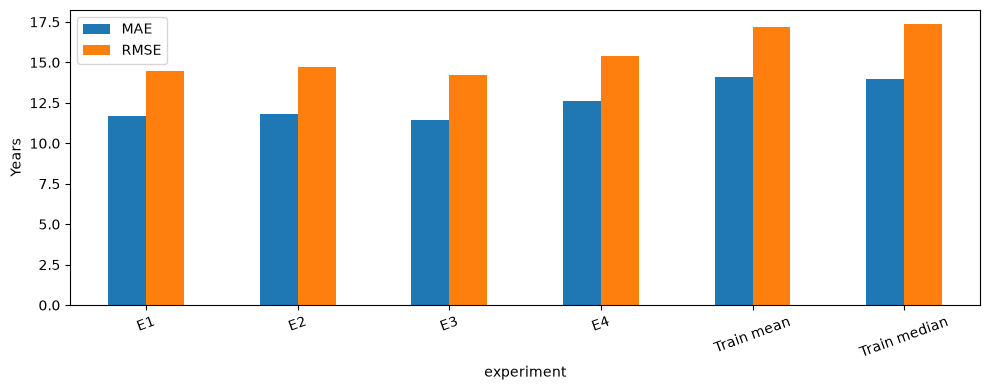

In [11]:
predictions = {}
if trained and MODE != "reload":
    test_rows = []
    test_dl = loader(splits["test"],eval_tf)
    for eid,loss_name,_ in EXPERIMENTS:
        ckpt = torch.load(RUN_DIR/f"{eid}_best.pth", map_location="cpu", weights_only=True)
        model = AgeCNN().to(DEVICE); model.load_state_dict(ckpt["state_dict"])
        _,yt,yp = epoch_pass(model,test_dl,nn.MSELoss() if loss_name=="MSE" else nn.L1Loss())
        pred = splits["test"][["Image Index","Patient ID","age"]].copy()
        assert np.allclose(pred.age,yt,atol=1e-4)
        pred["prediction"] = yp
        pred["residual"] = yp-pred.age
        pred["absolute_error"] = abs(pred.residual)
        pred.to_csv(RUN_DIR/f"{eid}_predictions.csv",index=False)
        predictions[eid] = pred
        test_rows.append({"experiment":eid,**metrics(pred.age,yp)})
        del model
    for name,value in [("Train mean",splits["train"].age.mean()),("Train median",splits["train"].age.median())]:
        test_rows.append({"experiment":name,**metrics(splits["test"].age,np.full(len(splits["test"]),value))})
    test_results = pd.DataFrame(test_rows)
    test_results.to_csv(RUN_DIR/"test_results.csv",index=False)
elif MODE=="reload":
    test_results = pd.read_csv(RUN_DIR/"test_results.csv")
    predictions = {eid:pd.read_csv(RUN_DIR/f"{eid}_predictions.csv",dtype={"Patient ID":str})
                   for eid,_,_ in EXPERIMENTS}
if trained:
    display(test_results.round(3))
    test_results.set_index("experiment")[["MAE","RMSE"]].plot.bar(figsize=(10,4))
    plt.ylabel("Years"); plt.xticks(rotation=20); plt.tight_layout(); save_figure("test_comparison")


## 10. Effects of Loss Function and Data Augmentation

The change in performance is measured using:

$$
\Delta = MAE_{\text{new}} - MAE_{\text{baseline}}
$$

A **negative $\Delta$** indicates a reduction in prediction error compared with the baseline condition.

Results obtained from a single random seed should be interpreted as **descriptive comparisons only**. They do not provide statistical evidence that one loss function will always outperform another.


In [12]:
if trained:
    val_mae = validation_results.set_index("experiment").val_MAE
    test_mae = test_results.set_index("experiment").MAE
    contrasts = []
    for label,old,new in [("MAE vs MSE, no augmentation","E1","E2"),
                          ("MAE vs MSE, augmentation","E3","E4"),
                          ("Augmentation với MSE","E1","E3"),
                          ("Augmentation với MAE","E2","E4")]:
        contrasts.append({"So sánh":label,"Delta validation MAE":val_mae[new]-val_mae[old],
                          "Delta test MAE":test_mae[new]-test_mae[old]})
    contrasts = pd.DataFrame(contrasts)
    display(contrasts.round(3)); contrasts.to_csv(RUN_DIR/"contrasts.csv",index=False)


,So sánh,Delta validation MAE,Delta test MAE
0,"MAE vs MSE, no augmentation",0.467,0.132
1,"MAE vs MSE, augmentation",1.311,1.161
2,Augmentation với MSE,-0.066,-0.263
3,Augmentation với MAE,0.778,0.765


## 11. Residual Analysis of the Validation-Selected Configuration

In the **Actual vs. Predicted** plot, points closer to the $y=x$ line indicate smaller prediction errors.

* Points **above** the $y=x$ line indicate that the model predicts an age higher than the actual age.
* Points **below** the $y=x$ line indicate that the model predicts an age lower than the actual age.

A residual histogram that is noticeably shifted away from zero may indicate prediction bias.

The **Residual vs. Age** plot can be used to examine whether the model tends to pull predictions toward the average patient age, particularly for younger and older patients.

The **Absolute Error Histogram** provides additional information about the distribution and frequency of large prediction errors.

Because this is a regression task, prediction errors should **not** be described using classification terms such as **False Positive (FP)** or **False Negative (FN)**.


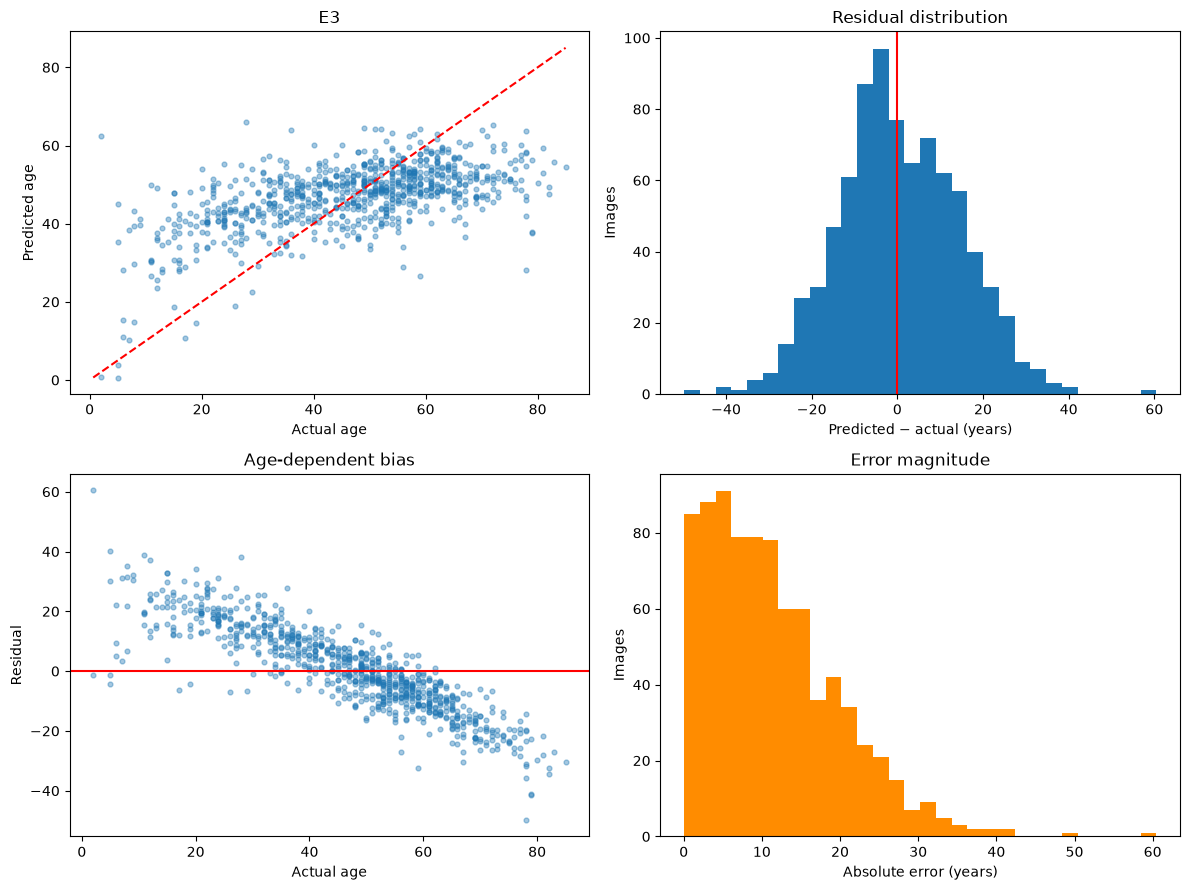

Số dự đoán ngoài phạm vi nghiên cứu: 2


In [13]:
if trained:
    pred = predictions[selected].copy()
    fig,axes = plt.subplots(2,2,figsize=(12,9))
    axes[0,0].scatter(pred.age,pred.prediction,s=12,alpha=.4)
    lo = min(pred.age.min(),pred.prediction.min()); hi = max(pred.age.max(),pred.prediction.max())
    axes[0,0].plot([lo,hi],[lo,hi],"r--")
    axes[0,0].set(xlabel="Actual age",ylabel="Predicted age",title=selected)
    axes[0,1].hist(pred.residual,bins=30); axes[0,1].axvline(0,color="red")
    axes[0,1].set(xlabel="Predicted − actual (years)",ylabel="Images",title="Residual distribution")
    axes[1,0].scatter(pred.age,pred.residual,s=12,alpha=.4); axes[1,0].axhline(0,color="red")
    axes[1,0].set(xlabel="Actual age",ylabel="Residual",title="Age-dependent bias")
    axes[1,1].hist(pred.absolute_error,bins=30,color="darkorange")
    axes[1,1].set(xlabel="Absolute error (years)",ylabel="Images",title="Error magnitude")
    plt.tight_layout(); save_figure("residual_analysis")
    print("Số dự đoán ngoài phạm vi nghiên cứu:",int((~pred.prediction.between(MIN_AGE,MAX_AGE)).sum()))


## 12. Age-Group Errors and Patient-Level Uncertainty

Age groups use **right-closed intervals**:

* `(0,20]`
* `(20,40]`
* `(40,60]`
* `(60,80]`
* `(80,100]`

For each age group, report both the **number of images** and the **number of unique patients** to avoid overinterpreting results from small groups.

For bootstrap analysis, resampling is performed at the **Patient ID level**, meaning that all images belonging to a selected patient are retained together.

Images from the same patient are **not** bootstrapped independently.

A **95% bootstrap interval** reflects the variability of the test cohort for the fixed model. It does not capture variability across different training seeds and does not establish clinical validity.


,images,patients,MAE,bias
age_group,,,,
1–20,69,47,20.979,20.474
21–40,214,170,13.289,12.971
41–60,360,281,6.093,-2.169
61–80,175,136,15.777,-15.765
81–100,6,6,29.020,-29.020


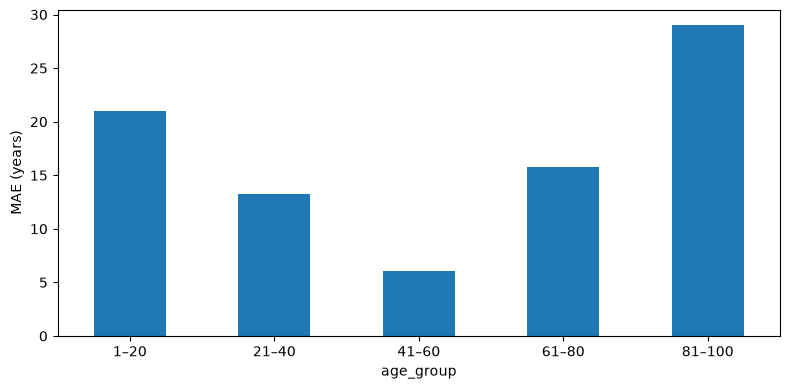

Image-weighted MAE, patient-cluster bootstrap 95% CI: [10.75, 12.16] năm
Patient-balanced MAE: 11.41 năm


In [14]:
if trained:
    pred["age_group"] = pd.cut(pred.age,[0,20,40,60,80,100],
                               labels=["1–20","21–40","41–60","61–80","81–100"],right=True)
    group_table = pred.groupby("age_group",observed=False).agg(
        images=("age","size"),patients=("Patient ID","nunique"),
        MAE=("absolute_error","mean"),bias=("residual","mean"))
    display(group_table.round(3)); group_table.to_csv(RUN_DIR/"age_group_metrics.csv")
    group_table.MAE.plot.bar(figsize=(8,4)); plt.ylabel("MAE (years)")
    plt.xticks(rotation=0); plt.tight_layout(); save_figure("age_groups")
    grouped = pred.groupby("Patient ID").absolute_error.agg(["sum","count"])
    rng = np.random.default_rng(SEED)
    scores = []
    for _ in range(1000):
        sampled = grouped.iloc[rng.integers(0,len(grouped),len(grouped))]
        scores.append(sampled["sum"].sum()/sampled["count"].sum())
    ci_low,ci_high = np.quantile(scores,[.025,.975])
    print(f"Image-weighted MAE, patient-cluster bootstrap 95% CI: [{ci_low:.2f}, {ci_high:.2f}] năm")
    print(f"Patient-balanced MAE: {pred.groupby('Patient ID').absolute_error.mean().mean():.2f} năm")


## 13. Good Predictions and Large Errors: Interpretation Using Real Examples

Select the **6 images with the smallest absolute errors** and the **6 images with the largest absolute errors**.

For each example, report:

* Actual age
* Predicted age
* Prediction error

These examples are deliberately selected from the extreme cases and are **not representative of the entire test set**.

The images alone are not sufficient to determine the medical cause of a prediction error. Therefore, the analysis should only record observable factors and potential hypotheses that require further verification, such as:

* Image quality
* Patient positioning
* Unusual or underrepresented age groups
* Potential metadata noise

These observations should be treated as hypotheses rather than definitive explanations for the model's prediction errors.


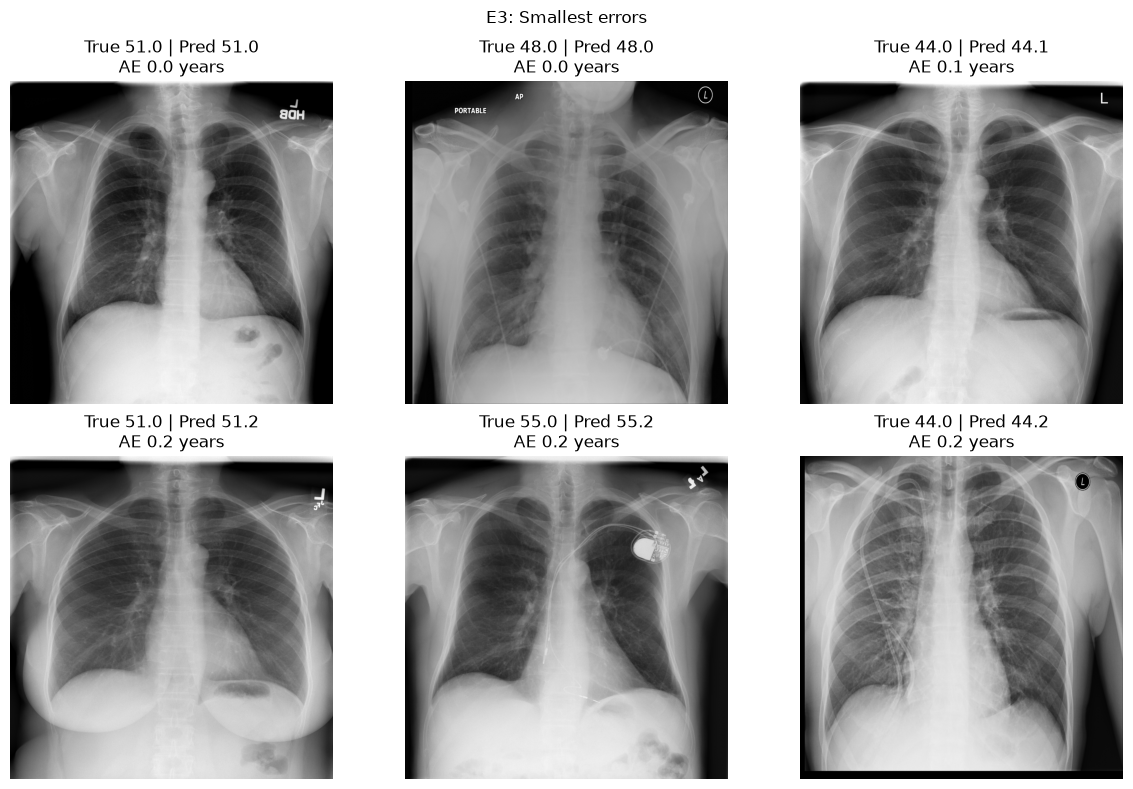

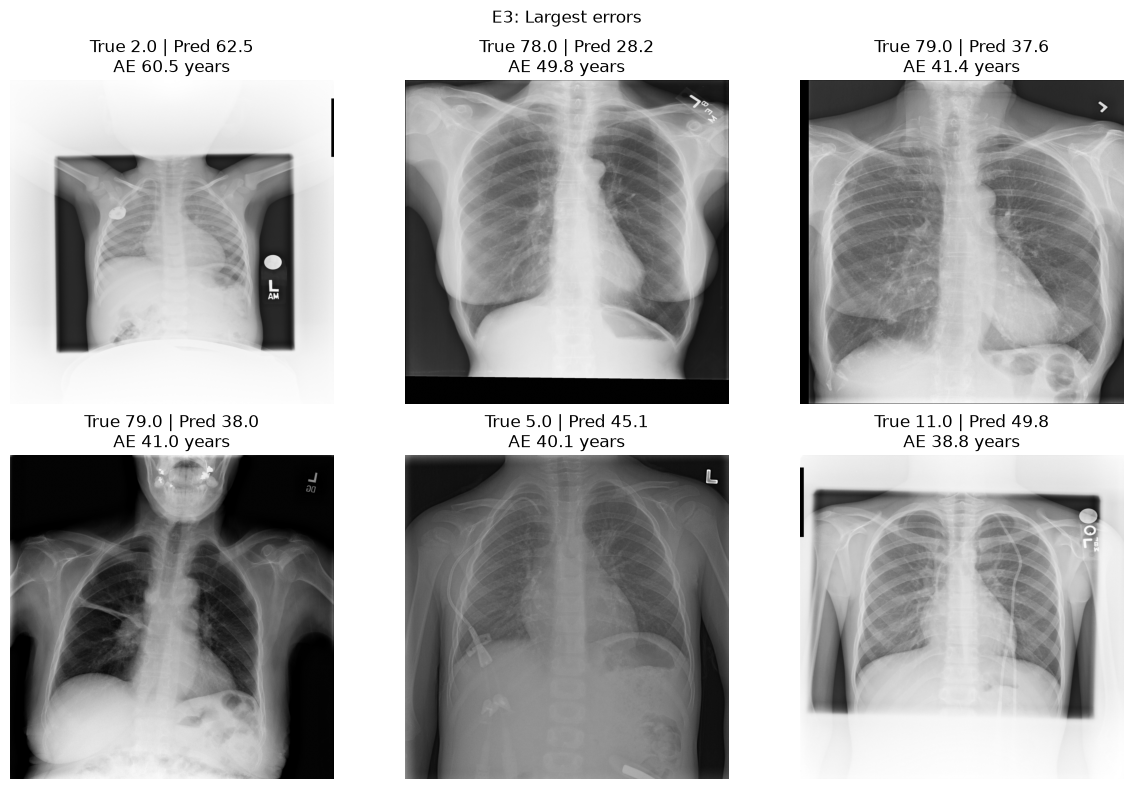

In [15]:
if trained:
    path_map = splits["test"].set_index("Image Index").image_path
    for title,examples in [("Smallest errors",pred.nsmallest(6,"absolute_error")),
                           ("Largest errors",pred.nlargest(6,"absolute_error"))]:
        fig,axes = plt.subplots(2,3,figsize=(12,8))
        for ax in axes.flat: ax.axis("off")
        for ax,(_,r) in zip(axes.flat,examples.iterrows()):
            with Image.open(path_map[r["Image Index"]]) as im:
                ax.imshow(im.convert("L"),cmap="gray")
            ax.set_title(f"True {r.age:.1f} | Pred {r.prediction:.1f}\nAE {r.absolute_error:.1f} years")
        fig.suptitle(f"{selected}: {title}")
        plt.tight_layout(); save_figure(title.lower().replace(" ","_"))


## 14. Automatic Conclusion Based on Experimental Results — No Fabricated Example Values

The conclusion below should describe **only the actual results obtained from the experiments**.

The group should supplement the numerical results with observations from the visualizations, an assessment of how representative the sample is, and a discussion of the hardware limitations encountered during training.

Do not conclude that data augmentation is beneficial if the corresponding $\Delta$ does not indicate a reduction in MAE.

The results from a single data split should not be described as demonstrating **“accurate age diagnosis”** or as evidence of clinical applicability.


In [16]:
if trained:
    s = test_results.set_index("experiment").loc[selected]
    b = test_results.set_index("experiment").loc["Train mean"]
    warning = "**CHỈ LÀ SMOKE TEST, KHÔNG DÙNG LÀM KẾT QUẢ CUỐI.**" if config["mode"]=="smoke" else ""
    report = f"""### Kết quả của nhóm
{warning}

Sử dụng {sum(len(v) for v in splits.values())} ảnh sau kiểm tra/chọn mẫu;
train/validation/test lần lượt {len(splits['train'])}/{len(splits['val'])}/{len(splits['test'])}.
Chọn **{selected}** bằng validation MAE, không bằng test.
Test MAE **{s.MAE:.2f} năm**, RMSE **{s.RMSE:.2f} năm**, MSE **{s.MSE:.2f} năm²**,
R² **{s.R2:.3f}**, bias **{s.Bias:.2f} năm**.
MAE giảm so với train-mean baseline **{b.MAE-s.MAE:.2f} năm** (âm nghĩa là kém hơn baseline).
Khoảng bootstrap theo bệnh nhân cho MAE: **[{ci_low:.2f}, {ci_high:.2f}] năm**.

Đây là kết quả trên Random Sample NIH, không phải toàn bộ NIH ChestX-ray14.
Một seed và một split chưa đủ để khẳng định cấu hình tối ưu; mô hình không dùng trong lâm sàng.
"""
    display(Markdown(report))
    (RUN_DIR/"summary_vi.md").write_text(report,encoding="utf-8")
else:
    print("Chưa huấn luyện: không có kết luận định lượng.")


### Kết quả của nhóm


Sử dụng 5604 ảnh sau kiểm tra/chọn mẫu;
train/validation/test lần lượt 3956/824/824.
Chọn **E3** bằng validation MAE, không bằng test.
Test MAE **11.43 năm**, RMSE **14.21 năm**, MSE **201.96 năm²**,
R² **0.316**, bias **0.58 năm**.
MAE giảm so với train-mean baseline **2.68 năm** (âm nghĩa là kém hơn baseline).
Khoảng bootstrap theo bệnh nhân cho MAE: **[10.75, 12.16] năm**.

Đây là kết quả trên Random Sample NIH, không phải toàn bộ NIH ChestX-ray14.
Một seed và một split chưa đủ để khẳng định cấu hình tối ưu; mô hình không dùng trong lâm sàng.


## 15. Reloading the Model for Single-Image Prediction (Optional)

Only load checkpoints created by the group or obtained from a trusted source.

The preprocessing pipeline used during inference must match the training configuration, including:

* Image size
* Grayscale conversion
* Padding
* Normalization
* Target age scaling

A checkpoint trained on a GPU can be loaded and used for inference on a CPU.

There is **no need to retrain the model** when demonstrating single-image inference for the presentation.



In [17]:
def predict_one(image_path, checkpoint_path):
    ckpt = torch.load(checkpoint_path,map_location="cpu",weights_only=True)
    net = AgeCNN().to(DEVICE)
    net.load_state_dict(ckpt["state_dict"]); net.eval()
    tf = transforms.Compose([Letterbox(ckpt["image_size"]),
                             transforms.ToTensor(),transforms.Normalize([.5],[.5])])
    with Image.open(image_path) as im:
        tensor = tf(im.convert("L")).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        value = net(tensor).item()*ckpt["age_scale"]
    return value

if trained:
    r = predictions[selected].iloc[0]
    prediction_again = predict_one(splits["test"].iloc[0].image_path,RUN_DIR/f"{selected}_best.pth")
    print("Ví dụ reload — tuổi dự đoán:",round(prediction_again,2))
    print("Sai khác với inference theo batch:",abs(prediction_again-r.prediction))


Ví dụ reload — tuổi dự đoán: 51.29
Sai khác với inference theo batch: 4.267692565917969e-05


## Conclusion

In this coursework, the team presented a workflow for addressing a **Medical Image Regression** problem, aiming to predict patient age from chest X-rays sourced from the **Random Sample of NIH Chest X-ray Dataset**. The **CNN + Global Average Pooling + Linear(1)** architecture was employed to meet the requirement of predicting a continuous value.

The experimental work focused on two key aspects: comparing **MAE Loss versus MSE Loss** and evaluating the impact of **data augmentation** across four configurations (E1–E4). Methodologies such as patient-based data splitting, checkpoint selection based on validation MAE, and baseline comparison ensured a robust evaluation of the model.

Determining the optimal configuration relies on actual results—specifically **MAE, MSE, RMSE, and R²**—complemented by analyses of residuals, errors across age groups, and instances of significant prediction errors. No single loss function or augmentation strategy can be universally declared superior beforehand.

Through this project, the team applied knowledge regarding image processing, CNN construction, model optimization, and regression evaluation. Future work will involve running multiple random seeds, testing on independent datasets, and improving performance for age groups with limited data representation. The current model is intended for academic purposes and lacks the necessary validation for clinical application.

 